# 📊 Feature Analysis & Selection
## Vietnamese Fake News Detection

Notebook này sẽ giúp bạn:
1. **So sánh** `num_fake` vs `benati`, `post_ratio` vs `violation_ratio`
2. **Chuyển đổi** một số features sang ratio
3. **Phân tích** phân phối features giữa tin giả và tin thật
4. **Đánh giá** khả năng phân tách của từng feature
5. **Đề xuất** features tốt nhất để training

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, ks_2samp
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Data
df = pd.read_csv("../data/raw/data.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Dataset shape: (4736, 26)

Columns: ['id', 'user_name', 'timestamp_post', 'post_message', 'label', 'num_char', 'num_emoji', 'num_url', 'num_hashtag', 'num_post', 'num_real', 'num_fake', 'post_ratio', 'num_like', 'num_cmt', 'num_share', 'pixel', 'image', 'num_image', 'hour', 'weekday', 'day', 'month', 'year', 'time', 'min']

Label distribution:
label
0    3929
1     807
Name: count, dtype: int64


## 1️⃣ So sánh num_fake vs benati, post_ratio vs violation_ratio

Kiểm tra xem các cột có sẵn trong dataset có giống với các cột tôi tạo từ function hay không.

In [3]:
# Tạo benati và violation_ratio từ function để so sánh
from preprocessing_functions import count_account_violations

# Tạo copy để test
df_test = df.copy()
df_test = count_account_violations(df_test, account_column='user_name', label_column='label', fake_label=1)

# So sánh num_fake vs benati
print("=" * 60)
print("SO SÁNH num_fake vs benati")
print("=" * 60)
print(f"\nSố dòng có num_fake == benati: {(df_test['num_fake'] == df_test['benati']).sum()}")
print(f"Số dòng có num_fake != benati: {(df_test['num_fake'] != df_test['benati']).sum()}")
print(f"Tổng số dòng: {len(df_test)}")

# Correlation
corr_fake = df_test['num_fake'].corr(df_test['benati'])
print(f"\nCorrelation giữa num_fake và benati: {corr_fake:.6f}")

# So sánh post_ratio vs violation_ratio
print("\n" + "=" * 60)
print("SO SÁNH post_ratio vs violation_ratio")
print("=" * 60)
print(f"\nSố dòng có post_ratio == violation_ratio: {(df_test['post_ratio'] == df_test['violation_ratio']).sum()}")
print(f"Số dòng có post_ratio != violation_ratio: {(df_test['post_ratio'] != df_test['violation_ratio']).sum()}")

# Correlation
corr_ratio = df_test['post_ratio'].corr(df_test['violation_ratio'])
print(f"\nCorrelation giữa post_ratio và violation_ratio: {corr_ratio:.6f}")

# Hiển thị vài dòng khác nhau (nếu có)
diff_rows = df_test[df_test['num_fake'] != df_test['benati']]
if len(diff_rows) > 0:
    print(f"\n⚠️ Có {len(diff_rows)} dòng khác nhau:")
    print(diff_rows[['user_name', 'num_fake', 'benati', 'post_ratio', 'violation_ratio']].head(10))
else:
    print("\n✅ Hai cặp cột hoàn toàn giống nhau! Có thể bỏ function count_account_violations.")

[4] Counting account violations...
    - Total unique accounts: 3446
    - Accounts with violations: 766
    - Created columns: 'benati', 'total_posts', 'violation_ratio'
SO SÁNH num_fake vs benati

Số dòng có num_fake == benati: 4699
Số dòng có num_fake != benati: 37
Tổng số dòng: 4736

Correlation giữa num_fake và benati: 0.985399

SO SÁNH post_ratio vs violation_ratio

Số dòng có post_ratio == violation_ratio: 4554
Số dòng có post_ratio != violation_ratio: 182

Correlation giữa post_ratio và violation_ratio: 0.999061

⚠️ Có 37 dòng khác nhau:
                             user_name  num_fake  benati  post_ratio  \
49    847ce0323d65cdbac24b65ebd38a7986         1       0         0.0   
81    847ce0323d65cdbac24b65ebd38a7986         1       0         0.0   
232   847ce0323d65cdbac24b65ebd38a7986         1       0         0.0   
277   847ce0323d65cdbac24b65ebd38a7986         1       0         0.0   
347   847ce0323d65cdbac24b65ebd38a7986         1       0         0.0   
390   847ce0323d

## 2️⃣ Phân tích các feature cần chuyển sang ratio

**Lý do chuyển sang ratio:**
- Các feature tuyệt đối (num_like, num_cmt, num_share) phụ thuộc vào độ viral của bài
- Ratio giúp normalize và so sánh công bằng giữa các bài
- Ví dụ: bài có 1000 like và 100 comment vs bài có 10 like và 1 comment → cùng ratio 10%

In [4]:
# Tạo các ratio features mới
df_analysis = df.copy()

# Engagement ratios
total_engagement = df_analysis['num_like'] + df_analysis['num_cmt'] + df_analysis['num_share']
df_analysis['like_ratio'] = df_analysis['num_like'] / (total_engagement + 1)  # +1 để tránh chia 0
df_analysis['cmt_ratio'] = df_analysis['num_cmt'] / (total_engagement + 1)
df_analysis['share_ratio'] = df_analysis['num_share'] / (total_engagement + 1)

# Comment to like ratio (bài fake thường có nhiều comment tranh cãi hơn)
df_analysis['cmt_to_like'] = df_analysis['num_cmt'] / (df_analysis['num_like'] + 1)

# Share to like ratio (bài thật thường được share nhiều hơn so với like)
df_analysis['share_to_like'] = df_analysis['num_share'] / (df_analysis['num_like'] + 1)

# Emoji và URL density (per character)
df_analysis['emoji_density'] = df_analysis['num_emoji'] / (df_analysis['num_char'] + 1)
df_analysis['url_density'] = df_analysis['num_url'] / (df_analysis['num_char'] + 1)
df_analysis['hashtag_density'] = df_analysis['num_hashtag'] / (df_analysis['num_char'] + 1)

print("Các ratio features mới được tạo:")
new_features = ['like_ratio', 'cmt_ratio', 'share_ratio', 'cmt_to_like', 'share_to_like', 
                'emoji_density', 'url_density', 'hashtag_density']
print(df_analysis[new_features].describe())

Các ratio features mới được tạo:
        like_ratio    cmt_ratio  share_ratio  cmt_to_like  share_to_like  \
count  4736.000000  4736.000000  4736.000000  4736.000000    4736.000000   
mean      0.679606     0.092086     0.107679     0.205073       0.430586   
std       0.258369     0.135387     0.159801     1.007815       4.675191   
min       0.000000     0.000000     0.000000     0.000000       0.000000   
25%       0.555556     0.000000     0.000000     0.000000       0.000000   
50%       0.750000     0.031250     0.050000     0.039046       0.060523   
75%       0.873774     0.133333     0.139037     0.196346       0.185185   
max       0.997690     0.917857     0.995025    50.000000     206.451613   

       emoji_density  url_density  hashtag_density  
count    4736.000000  4736.000000      4736.000000  
mean        0.000739     0.001719         0.000945  
std         0.003767     0.006302         0.003743  
min         0.000000     0.000000         0.000000  
25%         0.000

## 3️⃣ Đo lường khả năng phân biệt Fake vs Real của từng feature

**Các metrics được sử dụng:**
1. **Cohen's d**: Đo khoảng cách giữa 2 phân phối (effect size)
   - |d| > 0.8: large effect → feature tốt
   - |d| > 0.5: medium effect → feature khá
   - |d| > 0.2: small effect → feature yếu

2. **KS Statistic**: Đo sự khác biệt tối đa giữa 2 CDF
   - KS > 0.3: feature có khả năng phân biệt tốt

3. **T-test p-value**: Kiểm định sự khác biệt có ý nghĩa thống kê
   - p < 0.05: khác biệt có ý nghĩa

In [5]:
from scipy import stats

def compute_separation_metrics(df, feature_col, label_col='label', fake_label=1):
    """Tính các metrics đánh giá khả năng phân biệt của feature"""
    fake_values = df[df[label_col] == fake_label][feature_col].dropna()
    real_values = df[df[label_col] != fake_label][feature_col].dropna()
    
    # Cohen's d
    pooled_std = np.sqrt(((len(fake_values)-1)*fake_values.std()**2 + 
                          (len(real_values)-1)*real_values.std()**2) / 
                         (len(fake_values) + len(real_values) - 2))
    cohens_d = (fake_values.mean() - real_values.mean()) / (pooled_std + 1e-10)
    
    # KS statistic
    ks_stat, ks_pval = stats.ks_2samp(fake_values, real_values)
    
    # T-test
    t_stat, t_pval = stats.ttest_ind(fake_values, real_values)
    
    return {
        'feature': feature_col,
        'fake_mean': fake_values.mean(),
        'real_mean': real_values.mean(),
        'cohens_d': cohens_d,
        'ks_stat': ks_stat,
        'ks_pval': ks_pval,
        't_stat': t_stat,
        't_pval': t_pval
    }

# Danh sách tất cả features cần phân tích
numeric_features = [
    # Original features
    'num_char', 'num_emoji', 'num_url', 'num_hashtag', 'num_post',
    'num_real', 'num_fake', 'post_ratio',
    'num_like', 'num_cmt', 'num_share', 'pixel', 'num_image',
    'hour', 'weekday', 'day', 'month',
    # New ratio features
    'like_ratio', 'cmt_ratio', 'share_ratio', 'cmt_to_like', 'share_to_like',
    'emoji_density', 'url_density', 'hashtag_density'
]

# Tính metrics cho tất cả features
results = []
for feature in numeric_features:
    if feature in df_analysis.columns:
        metrics = compute_separation_metrics(df_analysis, feature)
        results.append(metrics)

# Tạo DataFrame kết quả và sắp xếp theo |Cohen's d|
results_df = pd.DataFrame(results)
results_df['abs_cohens_d'] = results_df['cohens_d'].abs()
results_df = results_df.sort_values('abs_cohens_d', ascending=False)

print("🎯 BẢNG XẾP HẠNG FEATURE THEO KHẢ NĂNG PHÂN BIỆT FAKE/REAL")
print("=" * 100)
print(results_df[['feature', 'fake_mean', 'real_mean', 'cohens_d', 'ks_stat', 't_pval']].to_string(index=False))

🎯 BẢNG XẾP HẠNG FEATURE THEO KHẢ NĂNG PHÂN BIỆT FAKE/REAL
        feature     fake_mean     real_mean  cohens_d  ks_stat       t_pval
     post_ratio      0.953532      0.008832 10.988286 0.971574 0.000000e+00
       num_fake      1.143742      0.076610  2.577809 0.949351 0.000000e+00
     like_ratio      0.545181      0.707217 -0.645284 0.247684 7.437617e-61
       num_real      0.339529     12.996182 -0.611288 0.915737 5.958674e-55
       num_post      1.483271     13.072792 -0.558998 0.256672 1.980076e-46
      cmt_ratio      0.143222      0.081583  0.462053 0.293734 1.778414e-32
           hour     13.337051     10.496564  0.456611 0.183424 9.135459e-32
    share_ratio      0.160352      0.096860  0.401784 0.103791 4.803275e-25
hashtag_density      0.000103      0.001118 -0.272610 0.099000 1.994912e-12
    url_density      0.000459      0.001978 -0.242028 0.124858 4.127639e-10
       num_like    799.646840   2759.263426 -0.241249 0.127550 4.691451e-10
        num_url      0.190830 

In [6]:
# Phân loại features theo mức độ hiệu quả
print("\n" + "=" * 80)
print("📊 PHÂN LOẠI FEATURES THEO MỨC ĐỘ HIỆU QUẢ")
print("=" * 80)

large_effect = results_df[results_df['abs_cohens_d'] >= 0.8]['feature'].tolist()
medium_effect = results_df[(results_df['abs_cohens_d'] >= 0.5) & (results_df['abs_cohens_d'] < 0.8)]['feature'].tolist()
small_effect = results_df[(results_df['abs_cohens_d'] >= 0.2) & (results_df['abs_cohens_d'] < 0.5)]['feature'].tolist()
negligible = results_df[results_df['abs_cohens_d'] < 0.2]['feature'].tolist()

print(f"\n🟢 LARGE EFFECT (|d| >= 0.8) - Rất tốt để train:")
print(f"   {large_effect if large_effect else 'Không có'}")

print(f"\n🟡 MEDIUM EFFECT (0.5 <= |d| < 0.8) - Tốt:")
print(f"   {medium_effect if medium_effect else 'Không có'}")

print(f"\n🟠 SMALL EFFECT (0.2 <= |d| < 0.5) - Có thể dùng:")
print(f"   {small_effect if small_effect else 'Không có'}")

print(f"\n🔴 NEGLIGIBLE (|d| < 0.2) - Nên loại bỏ:")
print(f"   {negligible if negligible else 'Không có'}")


📊 PHÂN LOẠI FEATURES THEO MỨC ĐỘ HIỆU QUẢ

🟢 LARGE EFFECT (|d| >= 0.8) - Rất tốt để train:
   ['post_ratio', 'num_fake']

🟡 MEDIUM EFFECT (0.5 <= |d| < 0.8) - Tốt:
   ['like_ratio', 'num_real', 'num_post']

🟠 SMALL EFFECT (0.2 <= |d| < 0.5) - Có thể dùng:
   ['cmt_ratio', 'hour', 'share_ratio', 'hashtag_density', 'url_density', 'num_like', 'num_url', 'num_hashtag', 'month']

🔴 NEGLIGIBLE (|d| < 0.2) - Nên loại bỏ:
   ['cmt_to_like', 'day', 'emoji_density', 'num_emoji', 'num_char', 'share_to_like', 'weekday', 'num_cmt', 'pixel', 'num_image', 'num_share']


## 4️⃣ Trực quan hóa - Boxplot so sánh Fake vs Real

Boxplot giúp nhìn trực quan sự phân tách giữa 2 nhóm Fake và Real cho các features quan trọng nhất.

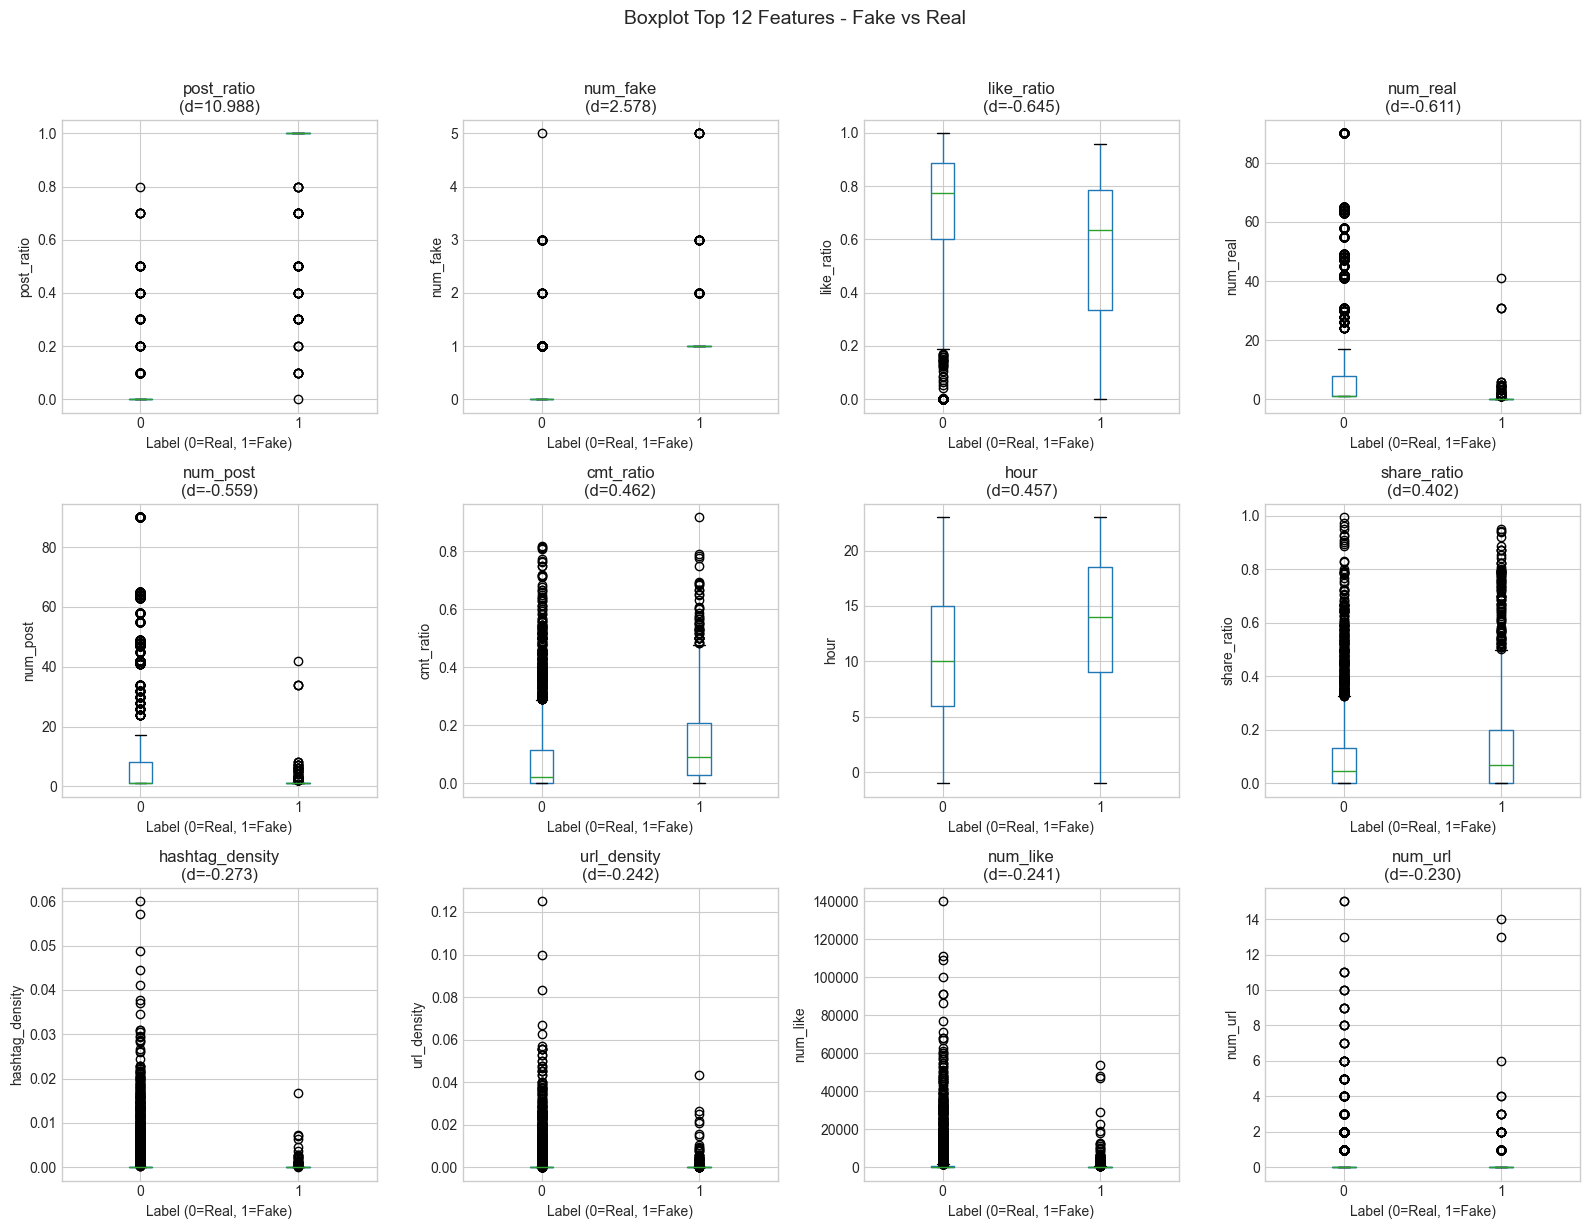

In [7]:
# Lấy top 12 features để vẽ
top_features = results_df.head(12)['feature'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    df_analysis.boxplot(column=feature, by='label', ax=ax)
    ax.set_title(f'{feature}\n(d={results_df[results_df["feature"]==feature]["cohens_d"].values[0]:.3f})')
    ax.set_xlabel('Label (0=Real, 1=Fake)')
    ax.set_ylabel(feature)

plt.suptitle('Boxplot Top 12 Features - Fake vs Real', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5️⃣ Trực quan hóa - KDE Plot (Phân phối xác suất)

KDE plot cho thấy rõ hơn sự chồng chéo giữa 2 phân phối. Nếu 2 đường cách xa nhau → feature tốt.

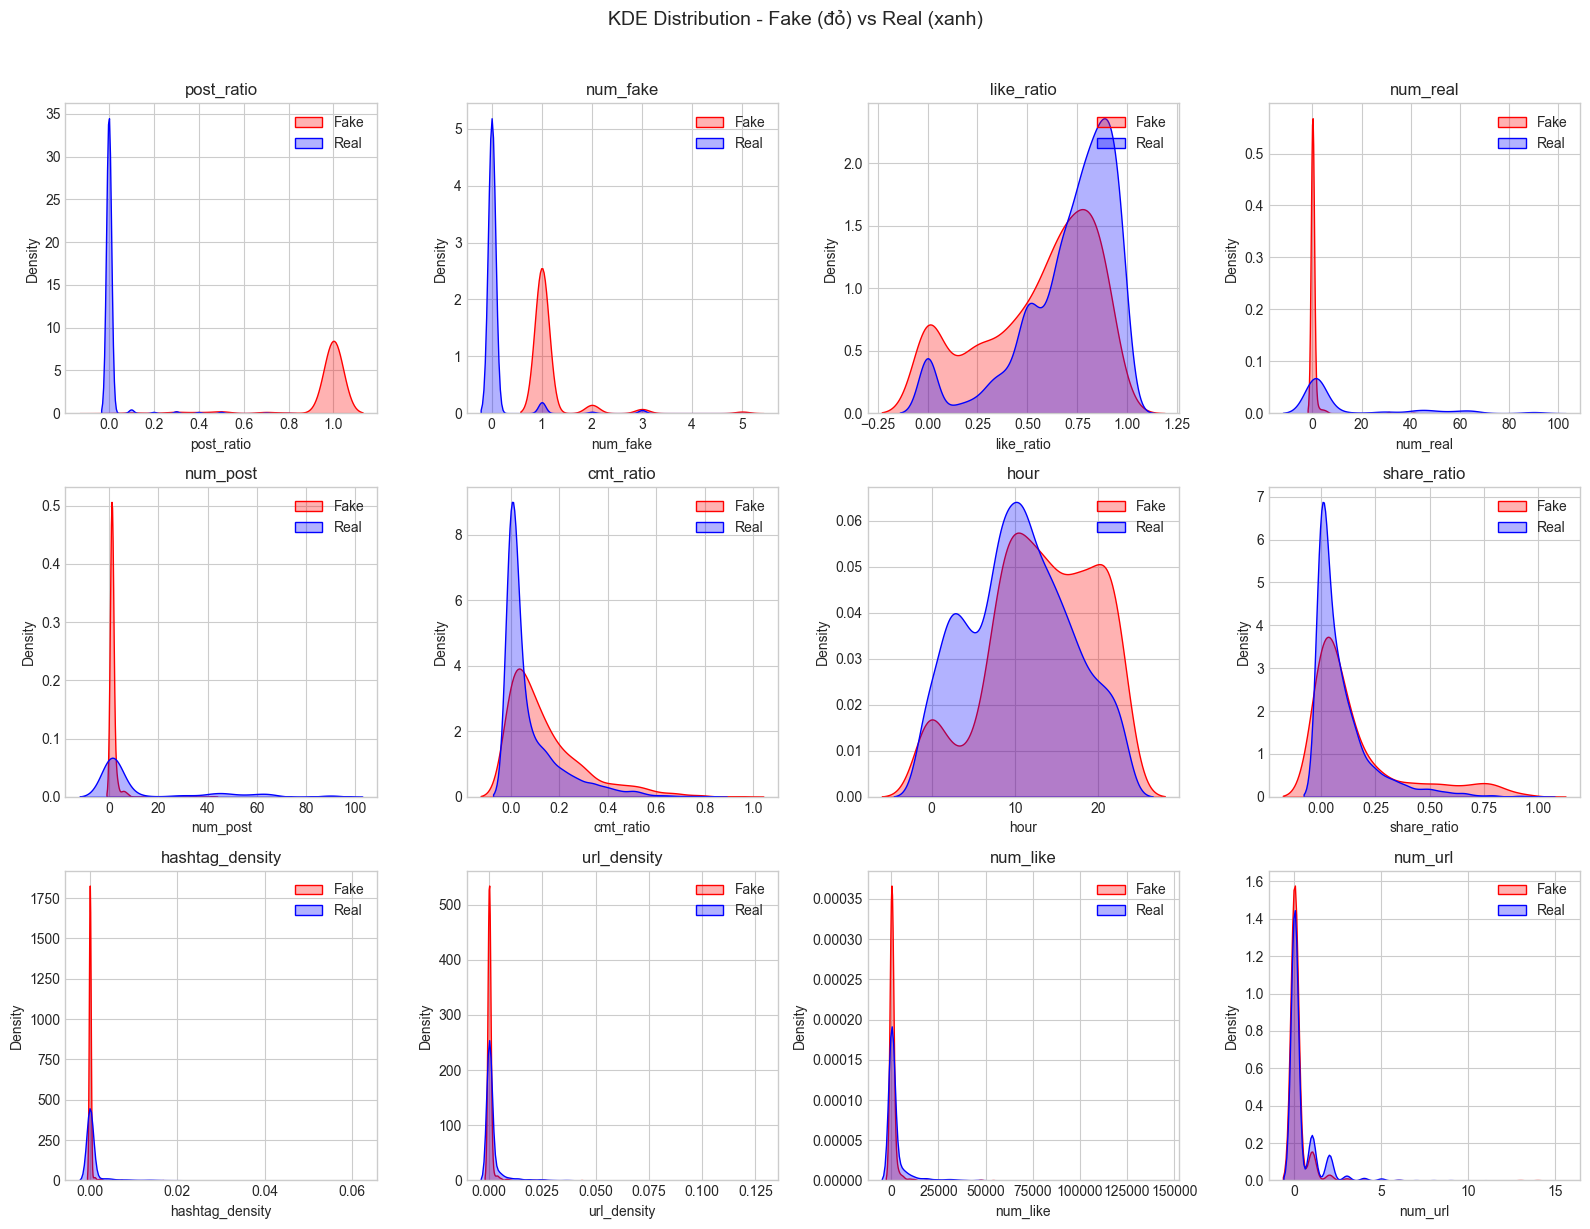

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    fake_data = df_analysis[df_analysis['label'] == 1][feature].dropna()
    real_data = df_analysis[df_analysis['label'] == 0][feature].dropna()
    
    sns.kdeplot(data=fake_data, ax=ax, label='Fake', color='red', fill=True, alpha=0.3)
    sns.kdeplot(data=real_data, ax=ax, label='Real', color='blue', fill=True, alpha=0.3)
    
    ax.set_title(f'{feature}')
    ax.legend()

plt.suptitle('KDE Distribution - Fake (đỏ) vs Real (xanh)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6️⃣ Correlation Matrix - Loại bỏ features trùng lặp

Features có correlation > 0.9 với nhau nên chỉ giữ 1 trong 2 để tránh multicollinearity.

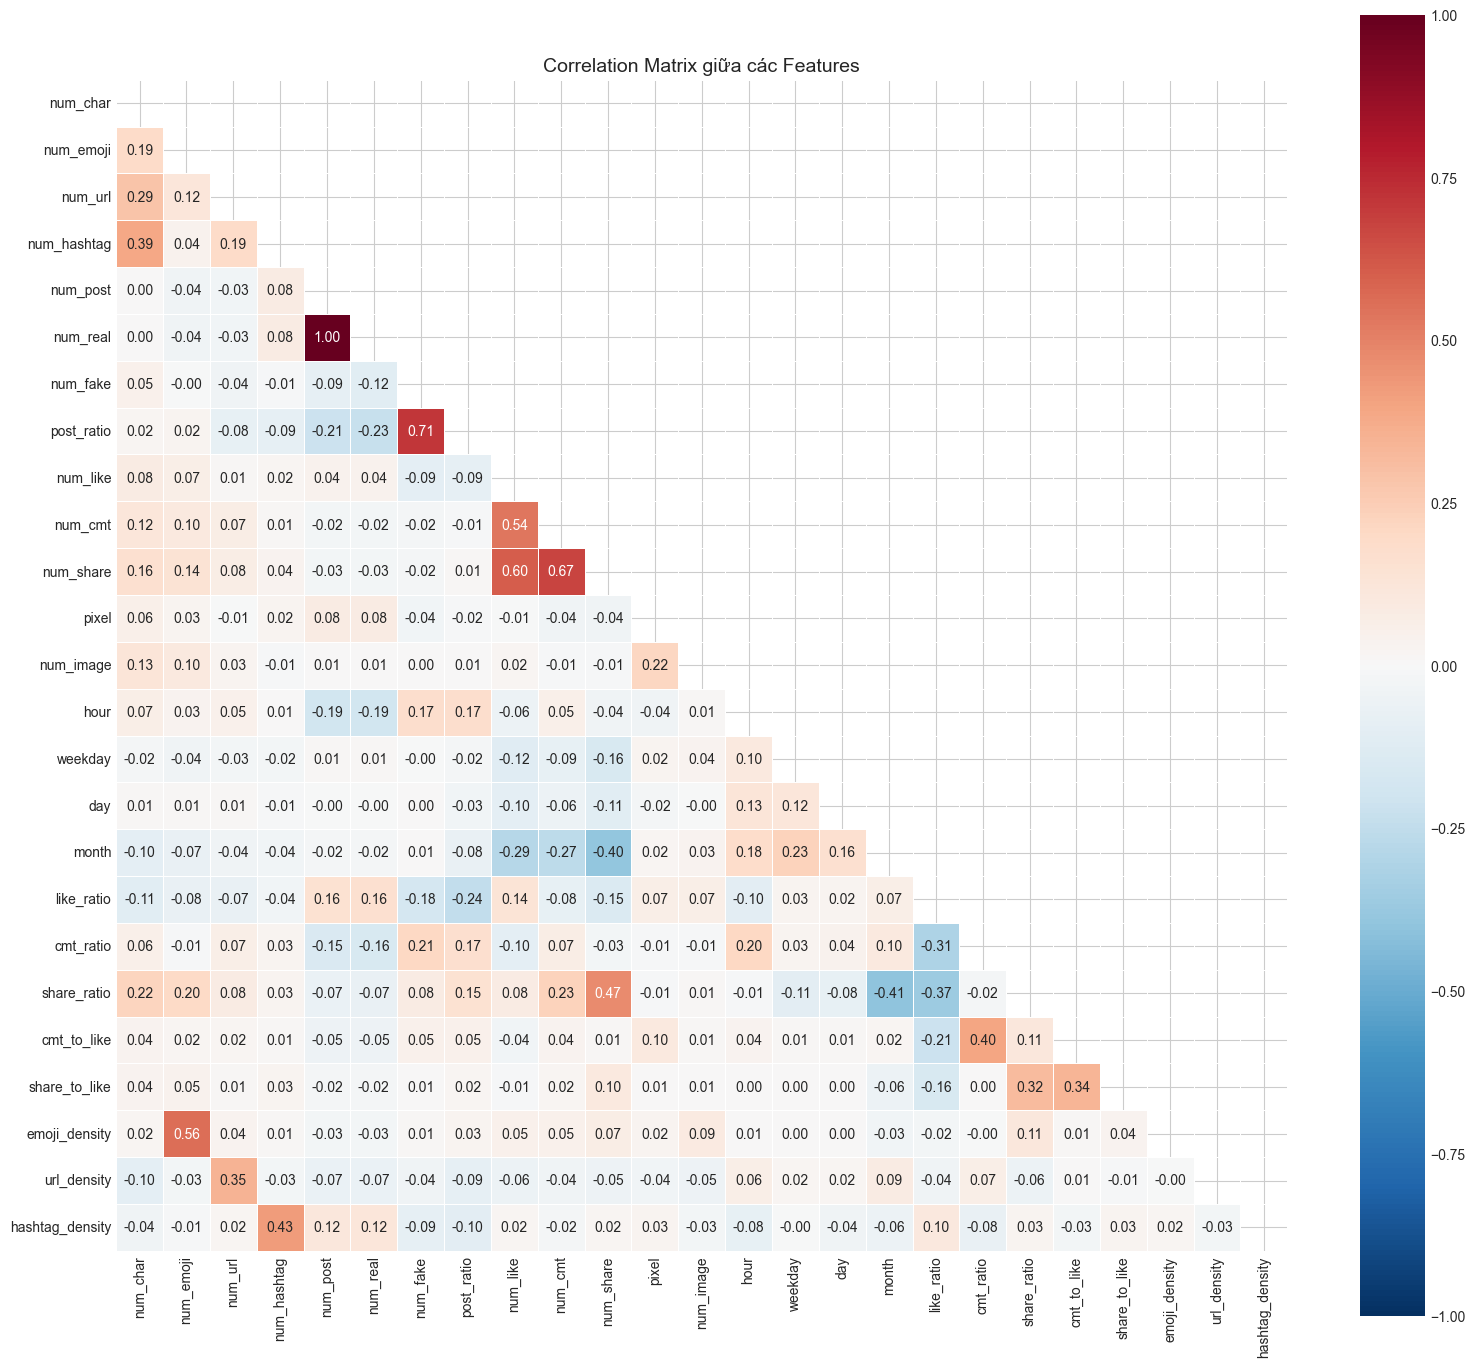


⚠️ CÁC CẶP FEATURES CÓ CORRELATION CAO (|r| > 0.8):
  num_post ↔ num_real: 1.000


In [9]:
# Tính correlation matrix
corr_matrix = df_analysis[numeric_features].corr()

# Vẽ heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix giữa các Features', fontsize=14)
plt.tight_layout()
plt.show()

# Tìm các cặp có correlation cao
print("\n⚠️ CÁC CẶP FEATURES CÓ CORRELATION CAO (|r| > 0.8):")
print("=" * 60)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

## 7️⃣ Feature Importance với Random Forest

Sử dụng Random Forest để đánh giá tầm quan trọng của từng feature trong việc phân loại Fake/Real.

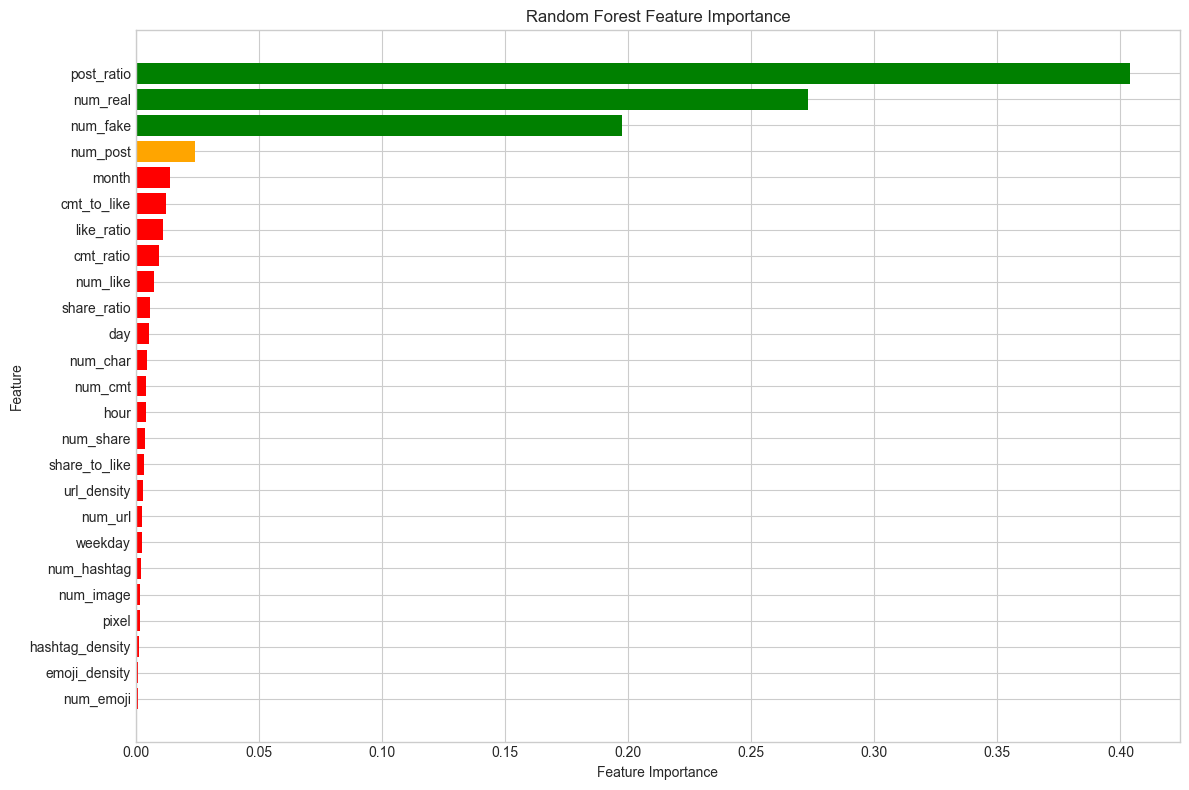


📊 BẢNG XẾP HẠNG FEATURE IMPORTANCE:
        feature  importance
     post_ratio    0.403994
       num_real    0.273233
       num_fake    0.197336
       num_post    0.024008
          month    0.013947
    cmt_to_like    0.012134
     like_ratio    0.010992
      cmt_ratio    0.009402
       num_like    0.007376
    share_ratio    0.005856
            day    0.005264
       num_char    0.004614
        num_cmt    0.004222
           hour    0.003968
      num_share    0.003827
  share_to_like    0.003212
    url_density    0.002863
        num_url    0.002481
        weekday    0.002462
    num_hashtag    0.002180
      num_image    0.001692
          pixel    0.001689
hashtag_density    0.001353
  emoji_density    0.001049
      num_emoji    0.000847


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Chuẩn bị data
X = df_analysis[numeric_features].fillna(0)
y = df_analysis['label']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

# Lấy feature importance
importance_df = pd.DataFrame({
    'feature': numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Vẽ barplot
plt.figure(figsize=(12, 8))
colors = ['green' if x >= 0.05 else 'orange' if x >= 0.02 else 'red' for x in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📊 BẢNG XẾP HẠNG FEATURE IMPORTANCE:")
print(importance_df.to_string(index=False))

## 8️⃣ Tổng hợp kết quả và Đề xuất cuối cùng

In [11]:
# Kết hợp cả Cohen's d và RF Importance để chọn features
combined_df = results_df.merge(importance_df, on='feature')
combined_df['combined_score'] = (
    combined_df['abs_cohens_d'] / combined_df['abs_cohens_d'].max() * 0.5 +
    combined_df['importance'] / combined_df['importance'].max() * 0.5
)
combined_df = combined_df.sort_values('combined_score', ascending=False)

print("🏆 BẢNG XẾP HẠNG TỔNG HỢP (Cohen's d + RF Importance)")
print("=" * 100)
print(combined_df[['feature', 'cohens_d', 'importance', 'combined_score']].to_string(index=False))

# Đề xuất cuối cùng
print("\n" + "=" * 80)
print("📋 ĐỀ XUẤT FEATURES CHO TRAINING")
print("=" * 80)

recommended = combined_df[combined_df['combined_score'] >= 0.3]['feature'].tolist()
maybe_use = combined_df[(combined_df['combined_score'] >= 0.15) & (combined_df['combined_score'] < 0.3)]['feature'].tolist()
not_recommended = combined_df[combined_df['combined_score'] < 0.15]['feature'].tolist()

print(f"\n✅ NÊN DÙNG (combined_score >= 0.3):")
print(f"   {recommended}")

print(f"\n⚠️ CÓ THỂ DÙNG (0.15 <= combined_score < 0.3):")
print(f"   {maybe_use}")

print(f"\n❌ KHÔNG NÊN DÙNG (combined_score < 0.15):")
print(f"   {not_recommended}")

print("\n" + "=" * 80)
print("💡 GỢI Ý THÊM:")
print("=" * 80)
print("""
1. Với các features tuyệt đối (num_like, num_cmt, num_share), hãy dùng thêm ratio version
2. Loại bỏ 1 trong 2 features có correlation > 0.9 (giữ feature có Cohen's d cao hơn)
3. Các features về thời gian (hour, weekday, month) có thể có pattern nhưng cần thêm feature engineering
4. Kết hợp với TF-IDF/PhoBERT embeddings của post_message để tăng accuracy
""")

🏆 BẢNG XẾP HẠNG TỔNG HỢP (Cohen's d + RF Importance)
        feature  cohens_d  importance  combined_score
     post_ratio 10.988286    0.403994        1.000000
       num_real -0.611288    0.273233        0.365981
       num_fake  2.577809    0.197336        0.361530
       num_post -0.558998    0.024008        0.055150
     like_ratio -0.645284    0.010992        0.042967
      cmt_ratio  0.462053    0.009402        0.032662
          month -0.204777    0.013947        0.026580
           hour  0.456611    0.003968        0.025688
    share_ratio  0.401784    0.005856        0.025530
    cmt_to_like  0.131544    0.012134        0.021003
       num_like -0.241249    0.007376        0.020106
    url_density -0.242028    0.002863        0.014556
hashtag_density -0.272610    0.001353        0.014079
        num_url -0.230125    0.002481        0.013542
    num_hashtag -0.225026    0.002180        0.012938
            day -0.082286    0.005264        0.010260
       num_char  0.062848    

## 9️⃣ Export danh sách features được chọn

In [13]:
# Lưu kết quả phân tích
combined_df.to_csv('../data/processed/feature_analysis_results.csv', index=False)

# Tạo dictionary các features để dùng trong training
selected_features = {
    'high_priority': recommended,
    'medium_priority': maybe_use,
    'all_recommended': recommended + maybe_use,
    'ratio_features': ['like_ratio', 'cmt_ratio', 'share_ratio', 'cmt_to_like', 
                       'share_to_like', 'emoji_density', 'url_density', 'hashtag_density']
}

import json
import os

os.makedirs('../data/processed', exist_ok=True)
with open('../data/processed/selected_features.json', 'w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2, ensure_ascii=False)

print("✅ Đã lưu kết quả vào:")
print("   - data/processed/feature_analysis_results.csv")
print("   - data/processed/selected_features.json")

print("\n📦 Features được chọn:")
print(json.dumps(selected_features, indent=2))

✅ Đã lưu kết quả vào:
   - data/processed/feature_analysis_results.csv
   - data/processed/selected_features.json

📦 Features được chọn:
{
  "high_priority": [
    "post_ratio",
    "num_real",
    "num_fake"
  ],
  "medium_priority": [],
  "all_recommended": [
    "post_ratio",
    "num_real",
    "num_fake"
  ],
  "ratio_features": [
    "like_ratio",
    "cmt_ratio",
    "share_ratio",
    "cmt_to_like",
    "share_to_like",
    "emoji_density",
    "url_density",
    "hashtag_density"
  ]
}
